In [81]:
try:
    %pip install --user "oracledb" --no-warn-script-location
except Exception as e:
    print("\x1b[31m\u2717 Unexpected error! Please contact course staff\n" +
         "Please include the entire text above and below in your message.")
    raise

Note: you may need to restart the kernel to use updated packages.


In [82]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu
import matplotlib.pyplot as plt

In [83]:
import oracledb

#Make sure to put in your user and password before running rest of code!
dsn = oracledb.makedsn("localhost", 1522, service_name="stu")
connection = oracledb.connect(
    user="ora_arthur0z",
    password="a80592421",
    dsn=dsn
)

cur = connection.cursor()

DatabaseError: ORA-02391: exceeded simultaneous SESSIONS_PER_USER limit
Help: https://docs.oracle.com/error-help/db/ora-02391/

In [ ]:
cur.execute("""
    SELECT DISTINCT m.movie_id, r.tomatoMeter, r.audienceScore
    FROM movies m
    JOIN movie_metrics r ON m.movie_id = r.movie_id
    JOIN oscar_nominations o ON m.movie_id = o.movie_id
""")
nominated_scores = cur.fetchall()

cur.execute("""
    SELECT DISTINCT m.movie_id, r.tomatoMeter, r.audienceScore
    FROM movies m
    JOIN movie_metrics r ON m.movie_id = r.movie_id
    WHERE m.movie_id NOT IN (SELECT movie_id FROM oscar_nominations)
""")
not_nominated_scores = cur.fetchall()

In [ ]:
nom_df = pd.DataFrame(nominated_scores, columns=['movie_id', 'Critic_Score', 'Audience_Score'])
not_nom_df = pd.DataFrame(not_nominated_scores, columns=['movie_id', 'Critic_Score', 'Audience_Score'])

critic_stat, critic_p = ttest_ind(nom_df['Critic_Score'], not_nom_df['Critic_Score'], equal_var=False)
aud_stat, aud_p = ttest_ind(nom_df['Audience_Score'], not_nom_df['Audience_Score'], equal_var=False)

print(f"Critic Score Difference   -> T-statistic: {critic_stat:.4f}, P-value: {critic_p:.4e}")
print(f"Audience Score Difference -> T-statistic: {aud_stat:.4f}, P-value: {aud_p:.4e}")

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Critic Scores
ax1.boxplot([nom_df['Critic_Score'], not_nom_df['Critic_Score']], tick_labels=['Nominated', 'Not Nominated'])
ax1.set_title('Critic Scores (TomatoMeter)')
ax1.set_ylabel('Score (0-100)')

# Plot 2: Audience Scores
ax2.boxplot([nom_df['Audience_Score'], not_nom_df['Audience_Score']], tick_labels=['Nominated', 'Not Nominated'])
ax2.set_title('Audience Scores')
ax2.set_ylabel('Score (0-100)')

plt.suptitle('Predictive Power of Scores for Oscar Nominations')
plt.tight_layout()
plt.show()

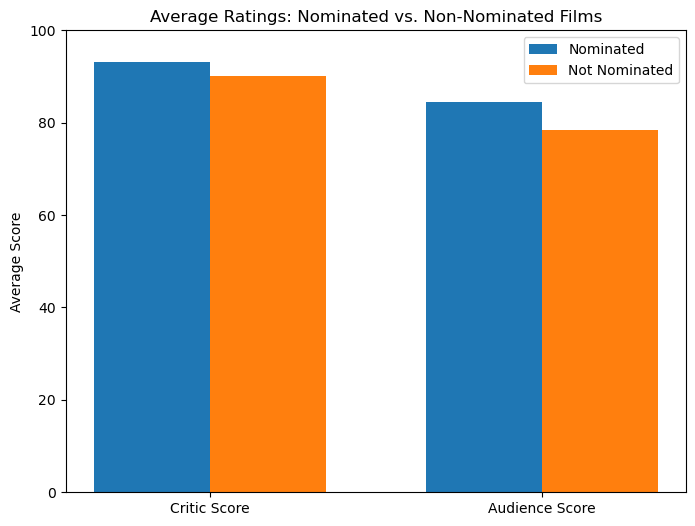

In [84]:
avg_nom_critic = nom_df['Critic_Score'].mean()
avg_not_nom_critic = not_nom_df['Critic_Score'].mean()

avg_nom_aud = nom_df['Audience_Score'].mean()
avg_not_nom_aud = not_nom_df['Audience_Score'].mean()

labels = ['Critic Score', 'Audience Score']
nominated_means = [avg_nom_critic, avg_nom_aud]
not_nominated_means = [avg_not_nom_critic, avg_not_nom_aud]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 6))
rects1 = ax.bar(x - width/2, nominated_means, width, label='Nominated')
rects2 = ax.bar(x + width/2, not_nominated_means, width, label='Not Nominated')

ax.set_ylabel('Average Score')
ax.set_title('Average Ratings: Nominated vs. Non-Nominated Films')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.set_ylim(0, 100)

plt.show()

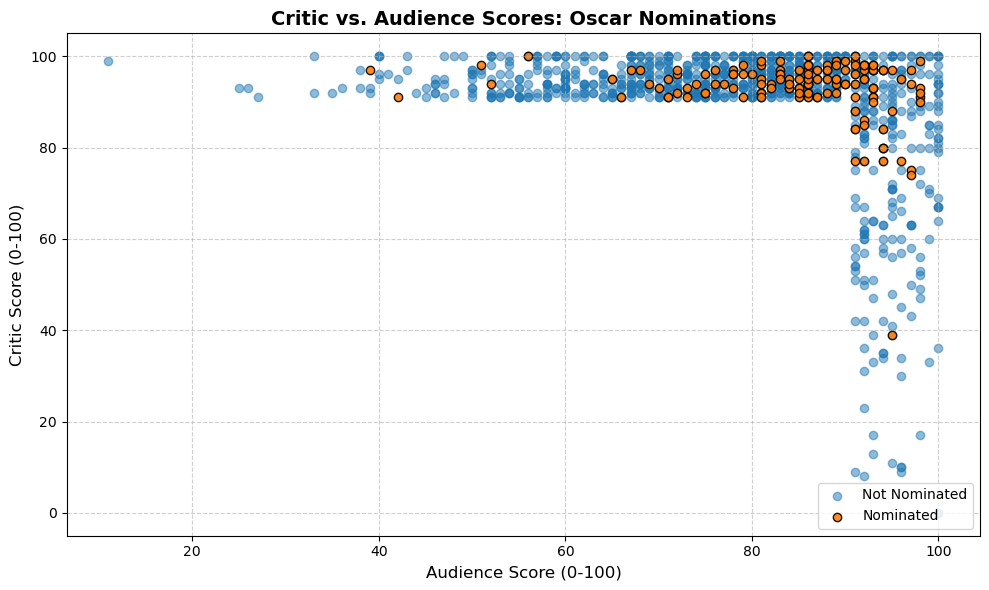

<Figure size 640x480 with 0 Axes>

In [85]:
fig, ax = plt.subplots(figsize=(10, 6)) 

ax.scatter(not_nom_df['Audience_Score'], not_nom_df['Critic_Score'], label='Not Nominated', alpha=0.5)

ax.scatter(nom_df['Audience_Score'], nom_df['Critic_Score'], edgecolors='black', label='Nominated', alpha=0.9)

ax.set_title('Critic vs. Audience Scores: Oscar Nominations', fontsize=14, fontweight='bold')
ax.set_xlabel('Audience Score (0-100)', fontsize=12)
ax.set_ylabel('Critic Score (0-100)', fontsize=12)

ax.legend(loc='lower right')
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

ax1.boxplot([nom_df['Critic_Score'], not_nom_df['Critic_Score']], tick_labels=['Nominated', 'Not Nominated'])
ax1.set_title('Critic Scores')
ax1.set_ylabel('Score (0-100)')

ax2.boxplot([nom_df['Audience_Score'], not_nom_df['Audience_Score']], tick_labels=['Nominated', 'Not Nominated'])
ax2.set_title('Audience Scores')
ax2.set_ylabel('Score (0-100)')
 
plt.suptitle('Predictive Power of Scores for Oscar Nominations')
plt.tight_layout() 
plt.show()

In [91]:
# Query 2
cur.execute("""
    SELECT 
        m.genre,
        COUNT(DISTINCT m.movie_id) AS total_released,
        COUNT(DISTINCT o.movie_id) AS total_nominated,
        ROUND(COUNT(DISTINCT o.movie_id) * 100.0 / COUNT(DISTINCT m.movie_id), 2) AS nomination_rate_pct
    FROM movies m
    LEFT JOIN oscar_nominations o ON m.movie_id = o.movie_id
    GROUP BY m.genre
    ORDER BY nomination_rate_pct DESC
""")
genre_data = cur.fetchall()

genre_df = pd.DataFrame(genre_data)
genre_df = genre_df.rename(columns={0: 'Genre', 1: 'Total_Released', 2: 'Total_Nominated', 3: 'Nomination_Rate'})

print(genre_df)

                                    Genre  Total_Released  Total_Nominated  \
0               Action, Adventure, Comedy               1                1   
1                 Western, Drama, Romance               1                1   
2                    Adventure, Animation               1                1   
3    Adventure, Drama, Mystery & thriller               1                1   
4        Biography, Comedy, Drama, Lgbtq+               1                1   
..                                    ...             ...              ...   
300                       Western, Action               1                0   
301       Western, Action, Horror, Comedy               1                0   
302                        Western, Drama               2                0   
303               Western, History, Drama               1                0   
304           Western, Mystery & thriller               1                0   

     Nomination_Rate  
0              100.0  
1              10

In [92]:
# Query 2
cur.execute("""
    SELECT 
        m.genre,
        COUNT(DISTINCT m.movie_id) AS total_released,
        COUNT(DISTINCT o.movie_id) AS total_nominated,
        ROUND(COUNT(DISTINCT o.movie_id) * 100.0 / COUNT(DISTINCT m.movie_id), 2) AS nomination_rate_pct
    FROM movies m
    LEFT JOIN oscar_nominations o ON m.movie_id = o.movie_id
    GROUP BY m.genre
    ORDER BY nomination_rate_pct DESC
""")
genre_data = cur.fetchall()

genre_df = pd.DataFrame(genre_data)
genre_df = genre_df.rename(columns={0: 'Genre', 1: 'Total_Released', 2: 'Total_Nominated', 3: 'Nomination_Rate'})

print(genre_df)

                                    Genre  Total_Released  Total_Nominated  \
0               Action, Adventure, Comedy               1                1   
1                 Western, Drama, Romance               1                1   
2                    Adventure, Animation               1                1   
3    Adventure, Drama, Mystery & thriller               1                1   
4        Biography, Comedy, Drama, Lgbtq+               1                1   
..                                    ...             ...              ...   
300                       Western, Action               1                0   
301       Western, Action, Horror, Comedy               1                0   
302                        Western, Drama               2                0   
303               Western, History, Drama               1                0   
304           Western, Mystery & thriller               1                0   

     Nomination_Rate  
0              100.0  
1              10

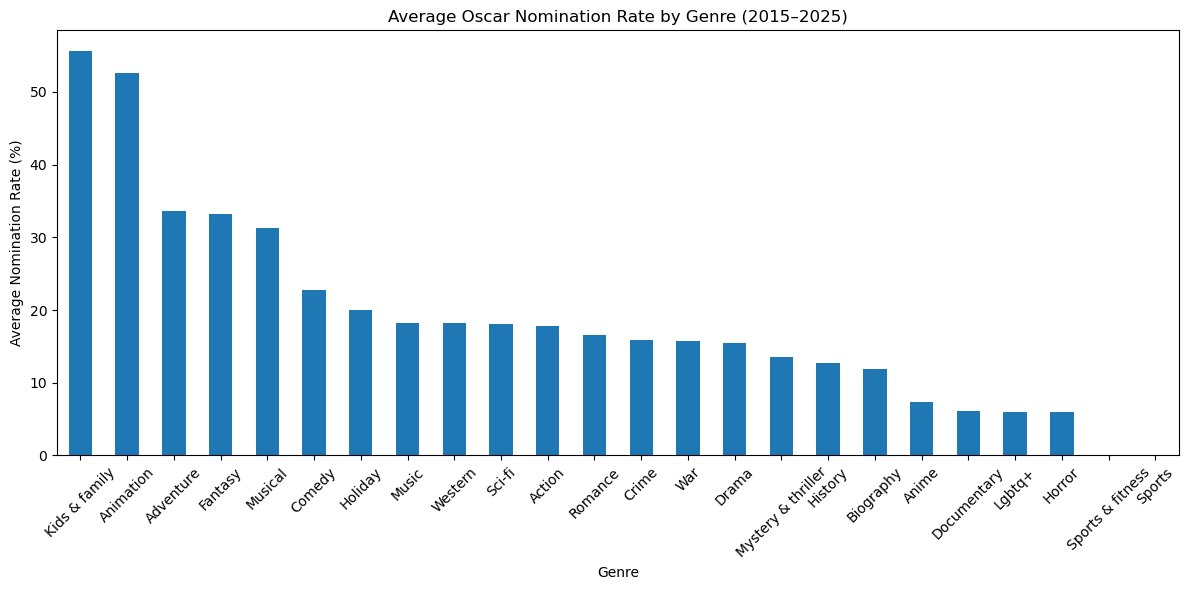

In [93]:
# Bar chart: Nomination rate by genre - Query 2

genre_df['Genre'] = genre_df['Genre'].str.split(',')
genre_df = genre_df.explode('Genre')
genre_df['Genre'] = genre_df['Genre'].str.strip()

genre_avg = genre_df.groupby('Genre')['Nomination_Rate'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))
genre_avg.plot(kind='bar')
plt.xticks(rotation=45)
plt.ylabel('Average Nomination Rate (%)')
plt.title('Average Oscar Nomination Rate by Genre (2015–2025)')
plt.tight_layout()
plt.show()

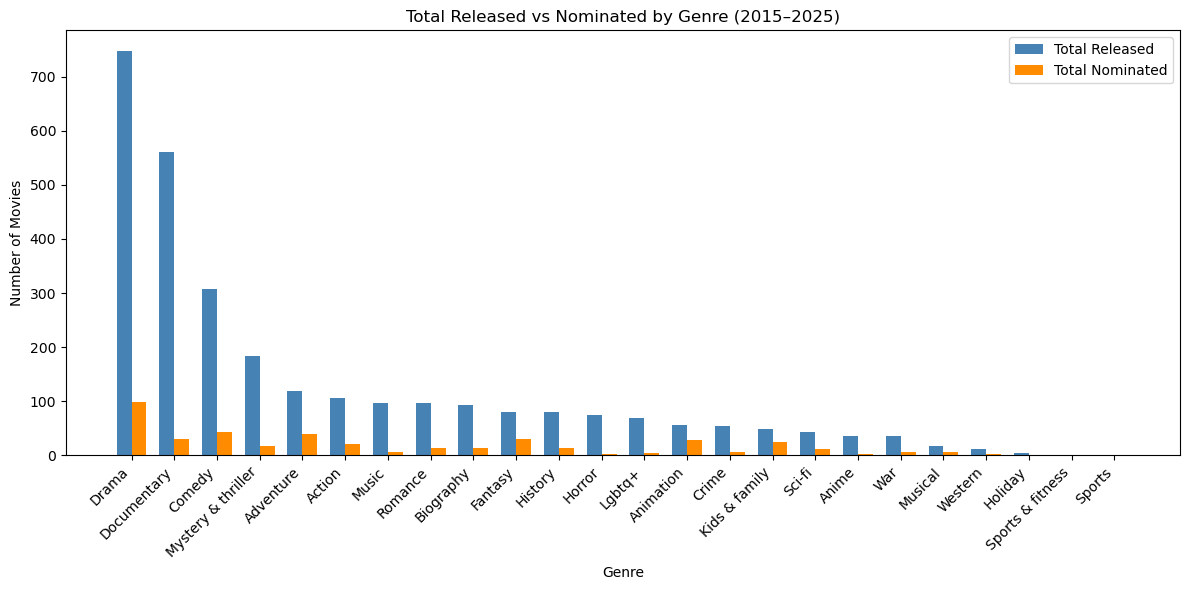

In [94]:
# Grouped bar chart: Total released vs nominated - Query 2

genre_summary = (
    genre_df.groupby('Genre', as_index=False)[['Total_Released', 'Total_Nominated']]
    .sum()
    .sort_values('Total_Released', ascending=False)
)

x = np.arange(len(genre_summary['Genre']))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, genre_summary['Total_Released'], width, label='Total Released', color='steelblue')
plt.bar(x + width/2, genre_summary['Total_Nominated'], width, label='Total Nominated', color='darkorange')
plt.xticks(x, genre_summary['Genre'], rotation=45, ha='right')
plt.xlabel('Genre')
plt.ylabel('Number of Movies')
plt.title('Total Released vs Nominated by Genre (2015–2025)')
plt.legend()
plt.tight_layout()
plt.show()

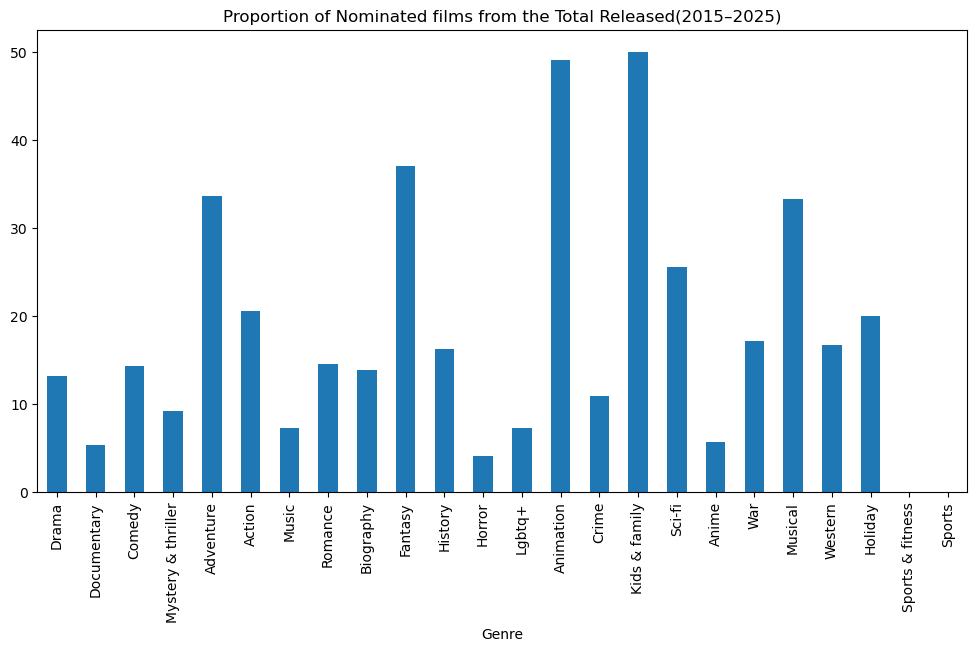

In [95]:
# Bar chart: Proportion of Nominated films from the Total Released - Query 2
genre_summary['Nomination_Rate'] = (
    genre_summary['Total_Nominated'] / genre_summary['Total_Released'] * 100
)

genre_summary.set_index('Genre')['Nomination_Rate'].plot(kind='bar', figsize=(12,6))
plt.title('Proportion of Nominated films from the Total Released(2015–2025)')
plt.show()

In [86]:
# Query 3
cur.execute("""
    SELECT year_ceremony AS year, COUNT(DISTINCT o.nomination_id) AS foreign_nomination_count 
    FROM oscar_nominations o JOIN movies m ON o.movie_id = m.movie_id 
    WHERE m.language != 'English' AND o.canon_category != 'BEST INTERNATIONAL FEATURE FILM' AND o.year_ceremony < 2020
    GROUP BY year_ceremony
""")

pre_2020 = cur.fetchall()

cur.execute("""
    SELECT year_ceremony AS year, COUNT(DISTINCT o.nomination_id) AS foreign_nomination_count 
    FROM oscar_nominations o JOIN movies m ON o.movie_id = m.movie_id 
    WHERE m.language != 'English' AND o.canon_category != 'BEST INTERNATIONAL FEATURE FILM' AND o.year_ceremony >= 2020
    GROUP BY year_ceremony
""")

post_2020 = cur.fetchall()

In [87]:
pre_2020_df = pd.DataFrame(pre_2020)
post_2020_df = pd.DataFrame(post_2020)

pre_2020_df = pre_2020_df.rename(columns={0: 'Year', 1: 'Nominations'})
post_2020_df = post_2020_df.rename(columns={0: 'Year', 1: 'Nominations'})

u_statistic, p_value = mannwhitneyu(pre_2020_df['Nominations'], post_2020_df['Nominations'], alternative='two-sided')
print(f"U-statistic: {u_statistic}")
print(f"P-value: {p_value}")

U-statistic: 6.0
P-value: 0.6631172453203822


In [88]:
foreign_noms = pd.concat([pre_2020_df, post_2020_df], ignore_index=True)
print(foreign_noms)

   Year  Nominations
0  2019           18
1  2017            9
2  2016            6
3  2018            4
4  2021            8
5  2022           14
6  2023            7
7  2020           14


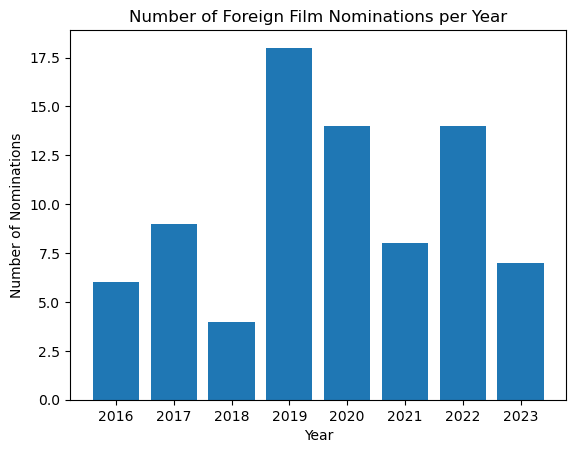

In [89]:
plt.bar(foreign_noms['Year'], foreign_noms['Nominations'])
plt.title('Number of Foreign Film Nominations per Year')
plt.xlabel('Year')
plt.ylabel('Number of Nominations')
plt.show()

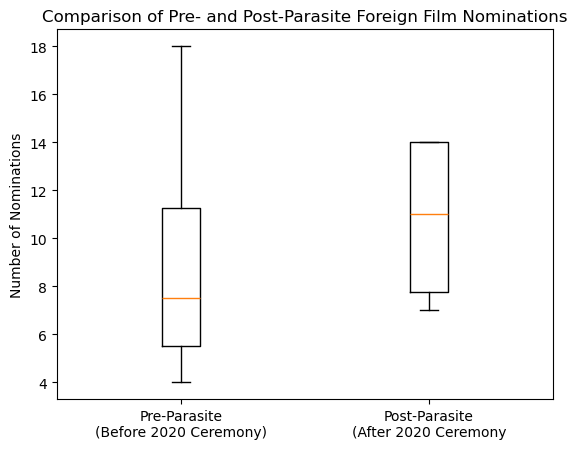

In [90]:
boxplot_data = [pre_2020_df['Nominations'], post_2020_df['Nominations']]
plt.boxplot(boxplot_data, tick_labels = ['Pre-Parasite\n(Before 2020 Ceremony)','Post-Parasite\n(After 2020 Ceremony'])
plt.title('Comparison of Pre- and Post-Parasite Foreign Film Nominations')
plt.ylabel('Number of Nominations')
plt.show()